In [1]:
from DMDcPlotter import DMDcPlotter
from DMDcDataset import DMDcDataset
import matplotlib.pyplot as plt
import os
import numpy as np
from TimeDelayedDMDc import TimeDelayedDMDc
from GroupedBasis import GroupedBasis
import pickle
#import importlib
#importlib.reload(DMDcPlotter)

Refer to the installation instructions at https://github.com/FlowModelingControl/flowtorch
If you are not using the TecplotDataloader, ignore this warning.


In [2]:
ref_dic_list = list()
path = "/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/dmdc/signal_library/cylinder2D/data/Random_walk"
reference_dic = {"u_inlet" : 1.0, "start_time": 3, "dim": "2d", "path": path, "signal":"Random walk"}
ref_dic_list.append(reference_dic)

path = "/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/dmdc/signal_library/cylinder2D/data/Chirp"
reference_dic = {"u_inlet" : 1.0, "start_time": 3, "dim": "2d", "path": path, "signal":"Chirp"}
ref_dic_list.append(reference_dic)

path = "/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/dmdc/signal_library/cylinder2D/data/Chirp_with_varying_ampl"
reference_dic = {"u_inlet" : 1.0, "start_time": 3, "dim": "2d", "path": path, "signal":"Chirp with varying ampl"}
ref_dic_list.append(reference_dic)

path = "/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/dmdc/signal_library/cylinder2D/data/AM"
reference_dic = {"u_inlet" : 1.0, "start_time": 3, "dim": "2d", "path": path, "signal":"AM"}
ref_dic_list.append(reference_dic)

In [3]:
groupedBasis = GroupedBasis(ref_dic_list)
common_Ur = groupedBasis.compute_basis(svd_rank = 60)
groupedBasis.clear_memory()

Shapes: p: (21250, 901) ux: (21250, 901) uy: (21250, 901) state_matrix: (63750, 901)
Shapes: p: (21250, 901) ux: (21250, 901) uy: (21250, 901) state_matrix: (63750, 901)
Shapes: p: (21250, 901) ux: (21250, 901) uy: (21250, 901) state_matrix: (63750, 901)
Shapes: p: (21250, 901) ux: (21250, 901) uy: (21250, 901) state_matrix: (63750, 901)


In [7]:
with open("common_Ur.pkl", "wb") as f:
    pickle.dump(common_Ur, f)

In [4]:
common_Ur.shape

(63750, 60)

## Random Walk

In [4]:
path = "/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/dmdc/signal_library/cylinder2D/data/Random_walk"
reference_dic = {"u_inlet" : 1.0, "cyl_radius": 0.05, "cyl_centre": (0.2, 0.2), "signal":"Random walk"}
random_walk = TimeDelayedDMDc(path, reference_dic, start_time=3, start_time_act = 4.0, dim="2d", q = 100, qu = 100, step = 1, stepU = 1, rank_dr = 60, U_dr = common_Ur)


Vertex arrays: (21250,) (21250,)
Shapes: p: (21250, 901) ux: (21250, 901) uy: (21250, 901) state_matrix: (63750, 901)
signal_matrix shape (100, 801)
Delayed matrices shapes: q: 100 step: 1 qu: 100 stepU 1 state_matrix_delayed: (6000, 802) signal_matrix_delayed: (100, 801)


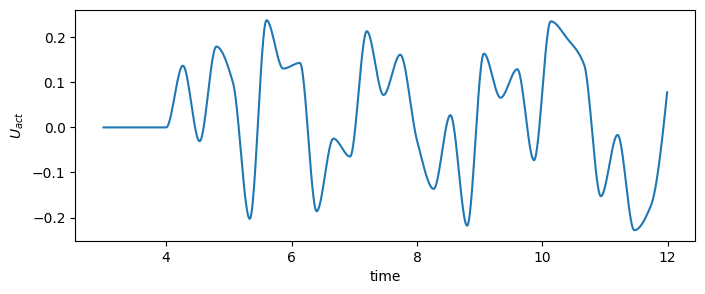

In [5]:
U_act = random_walk.signal_matrix.flatten()
t = np.asarray(random_walk.times_used, dtype=float)[:-1]   # keep your :-1
#t = random_walk.times_used[:-1]
plt.figure(figsize=(8, 3))
plt.plot(t, U_act)
plt.xlabel("time")
plt.ylabel(r"$U_{act}$")
plt.show()

In [5]:
random_walk.makeDMDcModel(svd_rank = 40)
random_walk.clear_memory()


/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/env/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 6044043.0. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


In [10]:
with open("random_walk_dmdc.pkl", "wb") as f:
    pickle.dump(random_walk.dmdc, f)

In [6]:
def compute_projection_error(dm, U, rank):
    Ur = U[:, :rank]
    return np.linalg.norm(dm - Ur @ (Ur.T @ dm), axis = 0) / np.linalg.norm(dm, axis=0)

In [7]:
pro_err_delayed_random_walk = compute_projection_error(random_walk.state_matrix_delayed, random_walk.dmdc["basis"], random_walk.dmdc["basis"].shape[1])


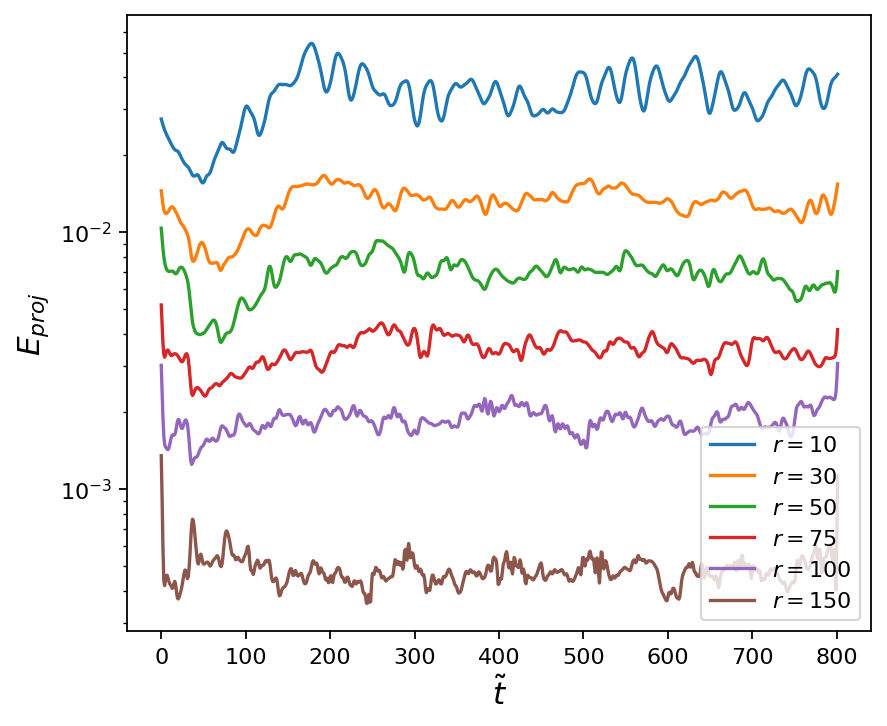

In [19]:
plt.figure(figsize = (6, 5), dpi = 160)

for i, r in enumerate(ranks):
    plt.plot( pro_err_train[i], c=f"C{i}", label=rf"$r={r:d}$")
plt.xlabel(r"$\tilde{t}$", fontsize = 14)
plt.ylabel(r"$E_{proj}$", fontsize = 14)
plt.legend()
plt.yscale("log")
#plt.savefig(f"{name}_proj.png", bbox_inches="tight")
plt.show()

## Chirp

In [6]:
path = "/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/dmdc/signal_library/cylinder2D/data/Chirp"
reference_dic = {"u_inlet" : 1.0, "cyl_radius": 0.05, "cyl_centre": (0.2, 0.2), "signal":"Chirp"}
chirp = TimeDelayedDMDc(path, reference_dic, start_time=3, start_time_act = 4.0, dim="2d", q = 100, qu = 100, step = 1, stepU = 1, rank_dr = 60, U_dr = common_Ur)


Vertex arrays: (21250,) (21250,)
Shapes: p: (21250, 901) ux: (21250, 901) uy: (21250, 901) state_matrix: (63750, 901)
signal_matrix shape (100, 801)
Delayed matrices shapes: q: 100 step: 1 qu: 100 stepU 1 state_matrix_delayed: (6000, 802) signal_matrix_delayed: (100, 801)


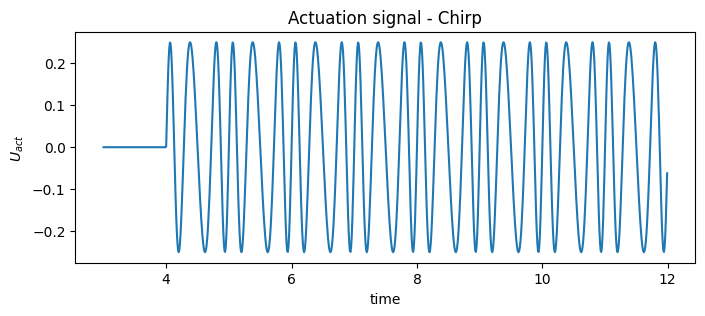

In [8]:
U_act = chirp.signal_matrix.flatten()
t = np.asarray(chirp.times_used, dtype=float)[:-1]   # keep your :-1
#t = random_walk.times_used[:-1]
plt.figure(figsize=(8, 3))
plt.plot(t, U_act)
plt.xlabel("time")
plt.ylabel(r"$U_{act}$")
plt.title("Actuation signal - Chirp")
plt.show()

In [7]:
chirp.makeDMDcModel(svd_rank=60)
chirp.clear_memory()


/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/env/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 481114816.0. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


In [13]:
with open("chirp_dmdc.pkl", "wb") as f:
    pickle.dump(chirp.dmdc, f)

In [11]:
pro_err_delayed_chirp = compute_projection_error(chirp.state_matrix_delayed, chirp.dmdc["basis"], chirp.dmdc["basis"].shape[1])


## Chirp with varying amplitude

In [8]:
path = "/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/dmdc/signal_library/cylinder2D/data/Chirp_with_varying_ampl"
reference_dic = {"u_inlet" : 1.0, "cyl_radius": 0.05, "cyl_centre": (0.2, 0.2), "signal":"Chirp with varying ampl"}
chirp_varying_amp = TimeDelayedDMDc(path, reference_dic, start_time=3, start_time_act = 4.0, dim="2d", q = 100, qu = 100, step = 1, stepU = 1, rank_dr = 60, U_dr = common_Ur)


Vertex arrays: (21250,) (21250,)
Shapes: p: (21250, 901) ux: (21250, 901) uy: (21250, 901) state_matrix: (63750, 901)
signal_matrix shape (100, 801)
Delayed matrices shapes: q: 100 step: 1 qu: 100 stepU 1 state_matrix_delayed: (6000, 802) signal_matrix_delayed: (100, 801)


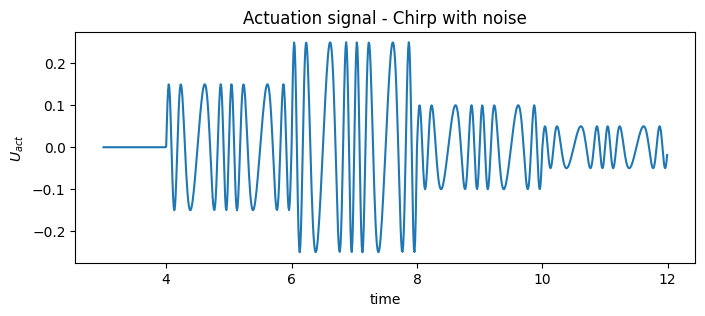

In [11]:
U_act = chirp_varying_amp.signal_matrix.flatten()
t = np.asarray(chirp_varying_amp.times_used, dtype=float)[:-1]   # keep your :-1
#t = random_walk.times_used[:-1]
plt.figure(figsize=(8, 3))
plt.plot(t, U_act)
plt.xlabel("time")
plt.ylabel(r"$U_{act}$")
plt.title("Actuation signal - Chirp with noise")
plt.show()

In [9]:
chirp_varying_amp.makeDMDcModel(svd_rank=60)
chirp_varying_amp.clear_memory()


/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/env/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 5027841.0. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


In [16]:
with open("chirp_varying_amp_dmdc.pkl", "wb") as f:
    pickle.dump(chirp_varying_amp.dmdc, f)

In [15]:
pro_err_delayed_chirp_varying_amp = compute_projection_error(chirp_varying_amp.state_matrix_delayed, chirp_varying_amp.dmdc["basis"], chirp_varying_amp.dmdc["basis"].shape[1])


## Ampitude Modulated signal

In [10]:
path = "/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/dmdc/signal_library/cylinder2D/data/AM"
reference_dic = {"u_inlet" : 1.0, "cyl_radius": 0.05, "cyl_centre": (0.2, 0.2), "signal":"AM"}
AM = TimeDelayedDMDc(path, reference_dic, start_time=3, start_time_act = 4.0, dim="2d", q = 100, qu = 100, step = 1, stepU = 1, rank_dr = 60, U_dr = common_Ur)


Vertex arrays: (21250,) (21250,)
Shapes: p: (21250, 901) ux: (21250, 901) uy: (21250, 901) state_matrix: (63750, 901)
signal_matrix shape (100, 801)
Delayed matrices shapes: q: 100 step: 1 qu: 100 stepU 1 state_matrix_delayed: (6000, 802) signal_matrix_delayed: (100, 801)


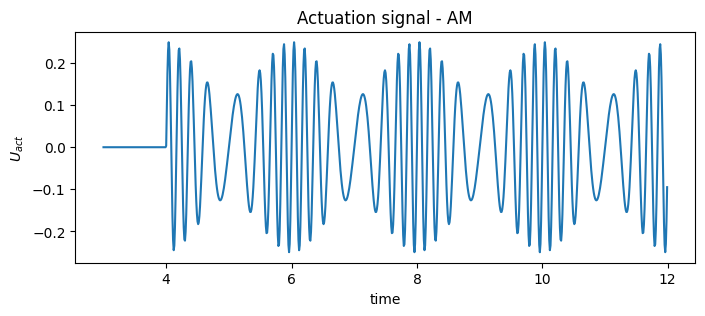

In [14]:
U_act = AM.signal_matrix.flatten()
t = np.asarray(AM.times_used, dtype=float)[:-1]   # keep your :-1
#t = random_walk.times_used[:-1]
plt.figure(figsize=(8, 3))
plt.plot(t, U_act)
plt.xlabel("time")
plt.ylabel(r"$U_{act}$")
plt.title("Actuation signal - AM")
plt.show()


In [11]:
AM.makeDMDcModel(svd_rank=60)
AM.clear_memory()


/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/env/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 4952596.0. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


In [19]:
with open("AM_dmdc.pkl", "wb") as f:
    pickle.dump(AM.dmdc, f)

In [19]:
pro_err_delayed_AM = compute_projection_error(AM.state_matrix_delayed, AM.dmdc["basis"], AM.dmdc["basis"].shape[1])


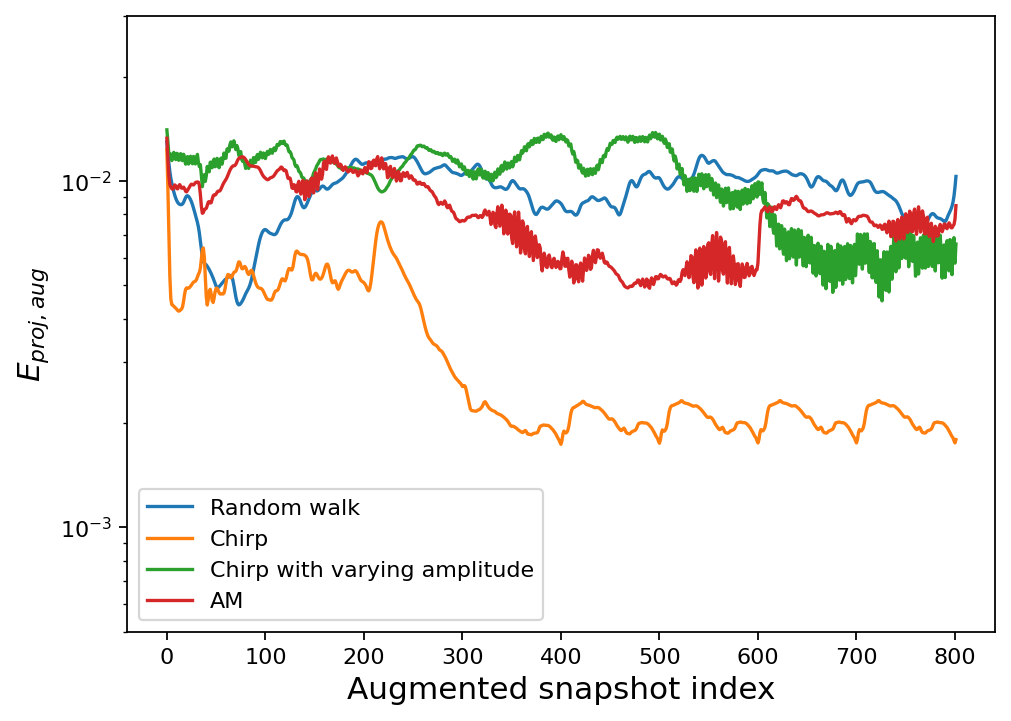

In [31]:
plt.figure(figsize = (7, 5), dpi = 160)
li_sigs_proj_err = [pro_err_delayed_random_walk, pro_err_delayed_chirp, pro_err_delayed_chirp_varying_amp, pro_err_delayed_AM]
labels = ["Random walk", "Chirp", "Chirp with varying amplitude", "AM"]
for i, li in enumerate(li_sigs_proj_err):
    plt.plot( li, c=f"C{i}", label=labels[i])
plt.xlabel(r"Augmented snapshot index", fontsize = 14)
plt.ylabel(r"$E_{proj, aug}$", fontsize = 14)
plt.legend()
plt.yscale("log")
plt.ylim((5e-4, 3e-2))
plt.savefig(f"all_proj_augmented.png", bbox_inches="tight")
plt.show()

In [12]:
path = "/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/dmdc/signal_library/cylinder2D/data/DRL_signal"
reference_dic = {"u_inlet" : 1.0, "cyl_radius": 0.05, "cyl_centre": (0.2, 0.2), "signal":"DRL_signal"}
DRL = TimeDelayedDMDc(path, reference_dic, start_time=4, start_time_act = 4.0, dim="2d", q = 100, qu = 100, step = 1, stepU = 1, rank_dr = 60, U_dr = common_Ur)

Vertex arrays: (21250,) (21250,)
Shapes: p: (21250, 401) ux: (21250, 401) uy: (21250, 401) state_matrix: (63750, 401)
signal_matrix shape (100, 301)
Delayed matrices shapes: q: 100 step: 1 qu: 100 stepU 1 state_matrix_delayed: (6000, 302) signal_matrix_delayed: (100, 301)


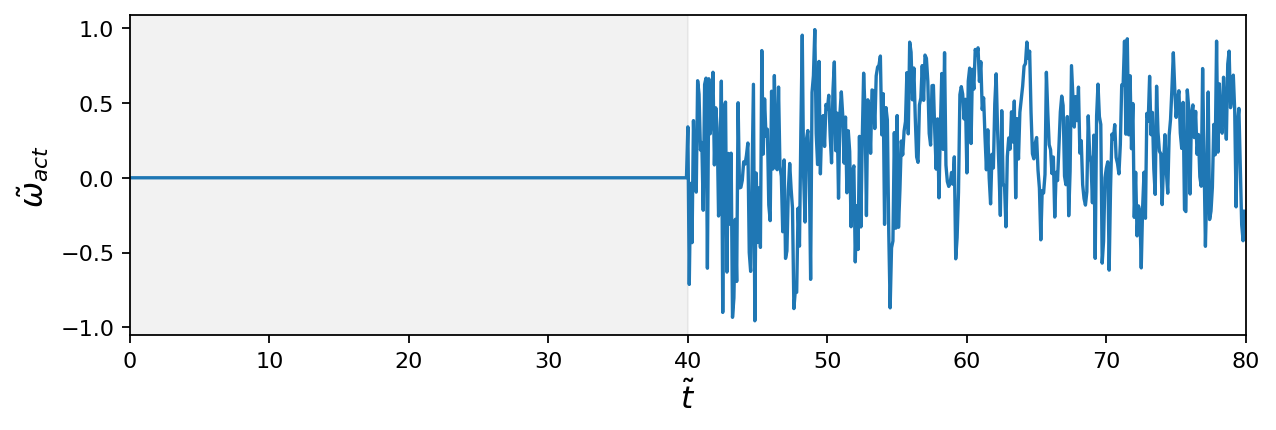

In [54]:
U_act = list(DRL.signal_matrix.flatten())
U_act.insert(0, 0)
U_act.insert(0, 0)
t = list(np.asarray(DRL.times_used, dtype=float)[:-1])   # keep your :-1
t.insert(0, 3.99)
t.insert(0, 0)
silence_until = 4
#t = random_walk.times_used[:-1]
plt.figure(figsize=(9, 2.6), dpi=160)
plt.plot(np.array(t)*10, np.array(U_act)/0.25)
plt.axvspan(0, silence_until*10, color='k', alpha=0.05, label='Silence')
plt.xlim((0,80))
plt.xticks(fontsize=16)
plt.yticks(fontsize=18)
plt.xlabel(r"$\tilde{t}$", fontsize = 22)
plt.ylabel(r"$\tilde{\omega}$", fontsize = 22)
plt.title("Valida", fontsize = 22)
#plt.title("Actuation signal - AM")
plt.savefig("validation_signal.png", bbox_inches="tight")  # or .png, .eps, etc.

plt.show()

In [13]:
DRL.makeDMDcModel(svd_rank=40)
DRL.clear_memory()

/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/env/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 1496878.125. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


## Compiling Results

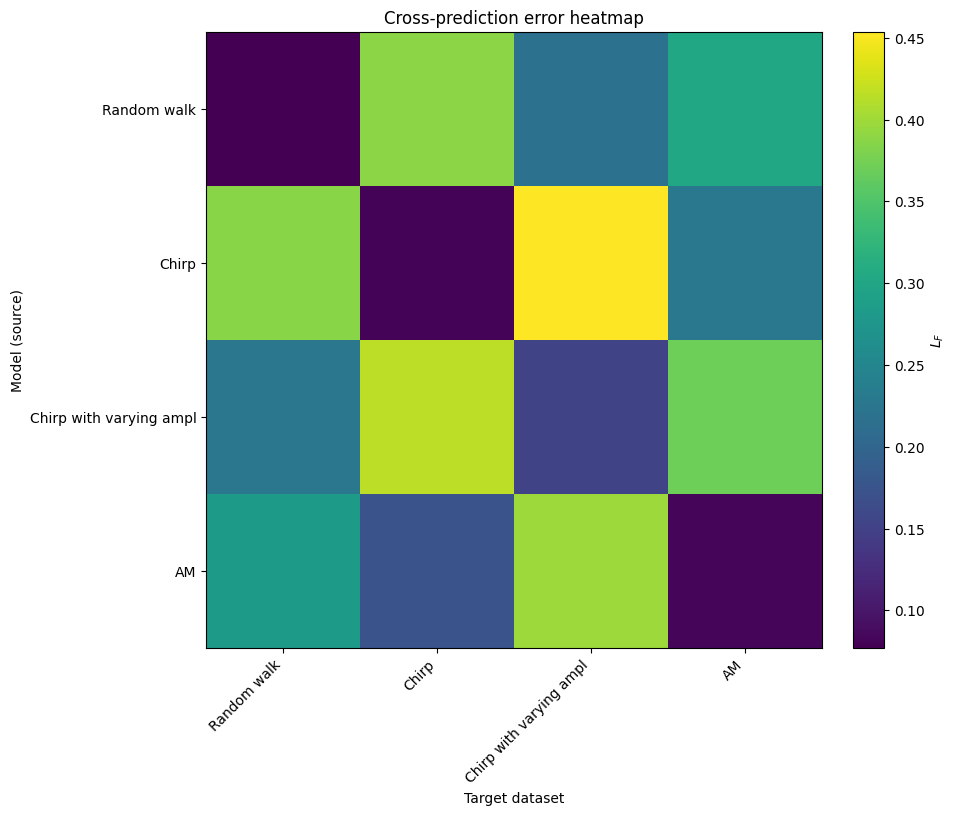

In [ ]:
plotter = DMDcPlotter([random_walk, chirp, chirp_varying_amp, AM])
err = plotter.cross_prediction_table()


In [15]:
data = plotter.get_predictions_for_signal_using_MORS(tgt_signal = DRL, steps_per_model = 1)

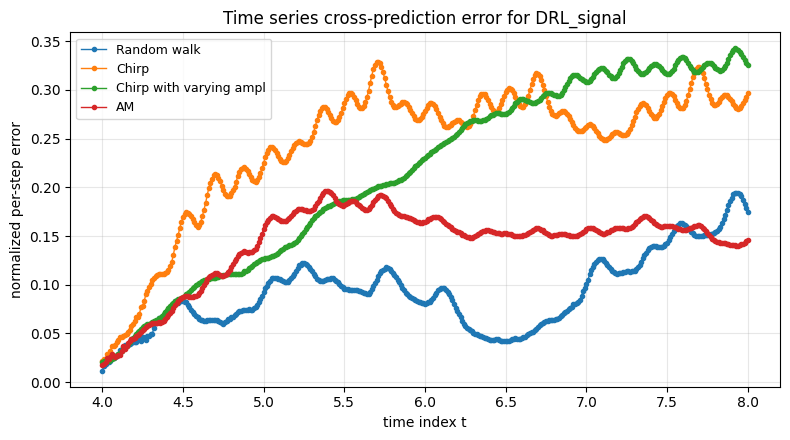

In [16]:
series, time, labels = plotter.plot_error_time_series_for_target_signal(DRL)


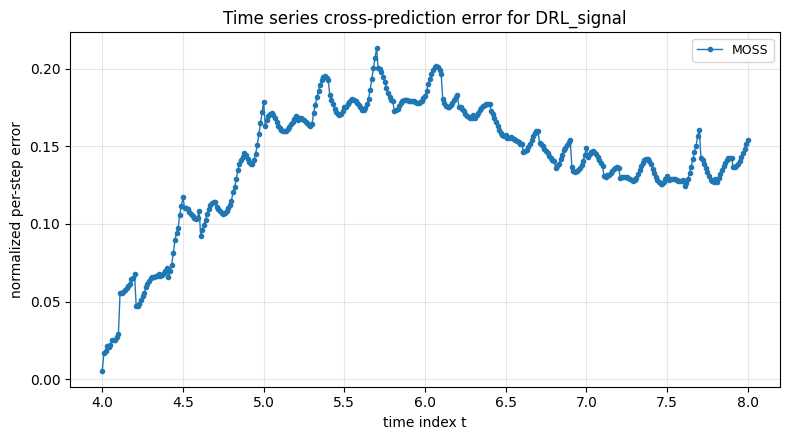

In [27]:
series_moss, time_moss = plotter.plot_error_time_series_for_target_signal_using_shuffling(DRL, 10)

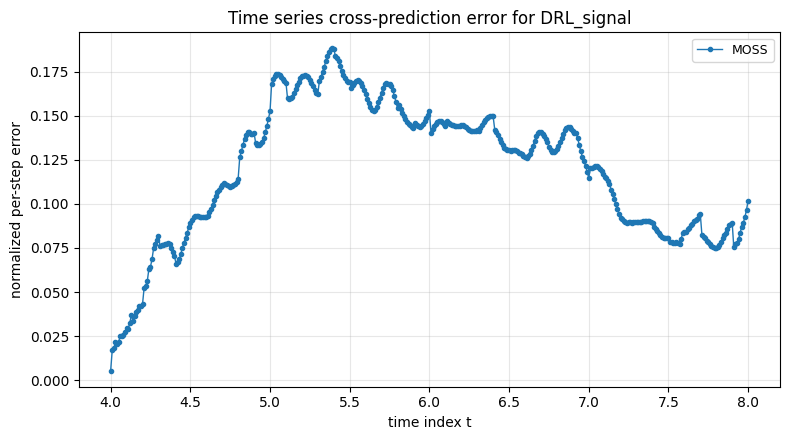

In [22]:
series_mors, time_mors = plotter.plot_error_time_series_for_target_signal_using_MORS(DRL, 10)

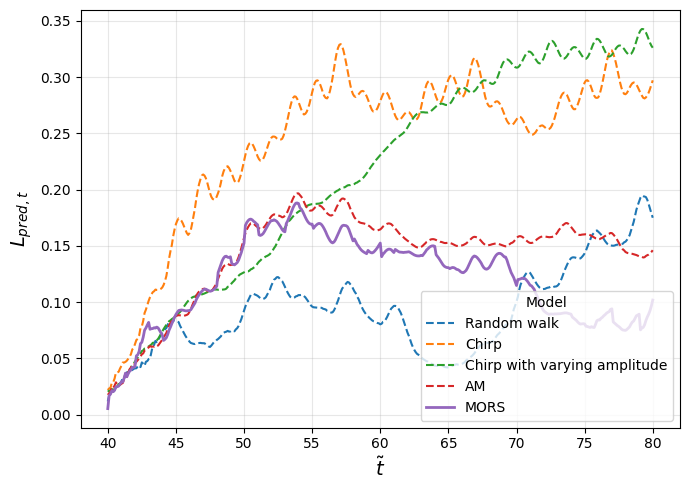

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
labels[2] = "Chirp with varying amplitude"
labels[0] = "Random walk"
for lbl, ser in zip(labels, series):
    ax.plot(time*10, ser, linewidth=1.5, label=lbl, linestyle = "--")
ax.plot(time_mors*10, series_mors, linewidth=2.0, label="MORS")
ax.set_xlabel(r"$\tilde{t}$", fontsize = 14)
ax.set_ylabel(r"$L_{pred, t}$", fontsize = 14)
#ax.set_title(f"Time series cross-prediction error for {lbl_tgt}")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=10, title = "Model")
plt.tight_layout()
fig.savefig("time_error_models.png", bbox_inches="tight")

plt.show()

In [16]:

import pickle, gzip
from pathlib import Path

# These are both dicts

# Where to save
out_dir = Path("exports")
out_dir.mkdir(parents=True, exist_ok=True)

# Filenames
data_path = out_dir / "data_new.pkl.gz"

# Save each dict separately (compressed)
with gzip.open(data_path, "wb") as f:
    pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved:\n  {data_path}")


Saved:
  exports/data_new.pkl.gz
